# 08 — Noise, Variance, SNR, and DM Exclusion

Detectability depends on both radio and gamma-ray noise. Radio noise combines
single-dish and interferometer modes; gamma-ray noise comes from Fermi-LAT
photon statistics with energy-dependent PSF. The Gaussian variance
$\Delta C_\ell$ enables SNR summation over $(\ell, E)$. DM sensitivity
is quantified by the $\Delta\chi^2$ test statistic.

**References:**

1. `docs/equations.md` §8 (Eqs. 8.1–8.16)
2. `docs/equations.md` §10 (Eqs. 10.1–10.4)

In [ ]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'hi_gamma_xcorr').is_dir():
            return candidate
    raise RuntimeError(f'Could not locate repo root from {start}')

REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from hi_gamma_xcorr import config as cfg, cosmology as cosmo
from hi_gamma_xcorr import plotting as sty
cosmo.init()
print("Pipeline initialized.")

Pipeline initialized.


In [ ]:
from hi_gamma_xcorr import noise_model as nm, statistics as stats
from hi_gamma_xcorr import angular_power as ap

## 1. System Temperature Models (Eqs. 8.1, 8.1b)

$$T_\mathrm{sys}^\mathrm{Pin}(\nu) = 30 + 60\,(300/\nu_\mathrm{MHz})^{2.55}\;\mathrm{K}$$

$$T_\mathrm{sys}^\mathrm{MK}(\nu) = T_\mathrm{rx} + T_\mathrm{spl} + T_\mathrm{CMB} + T_\mathrm{gal}$$

The MeerKAT model (**D16**) gives $\sim 16$ K at L-band vs $\sim 32$ K for
the Pinetti generic formula --- a factor-of-4 difference in noise power.

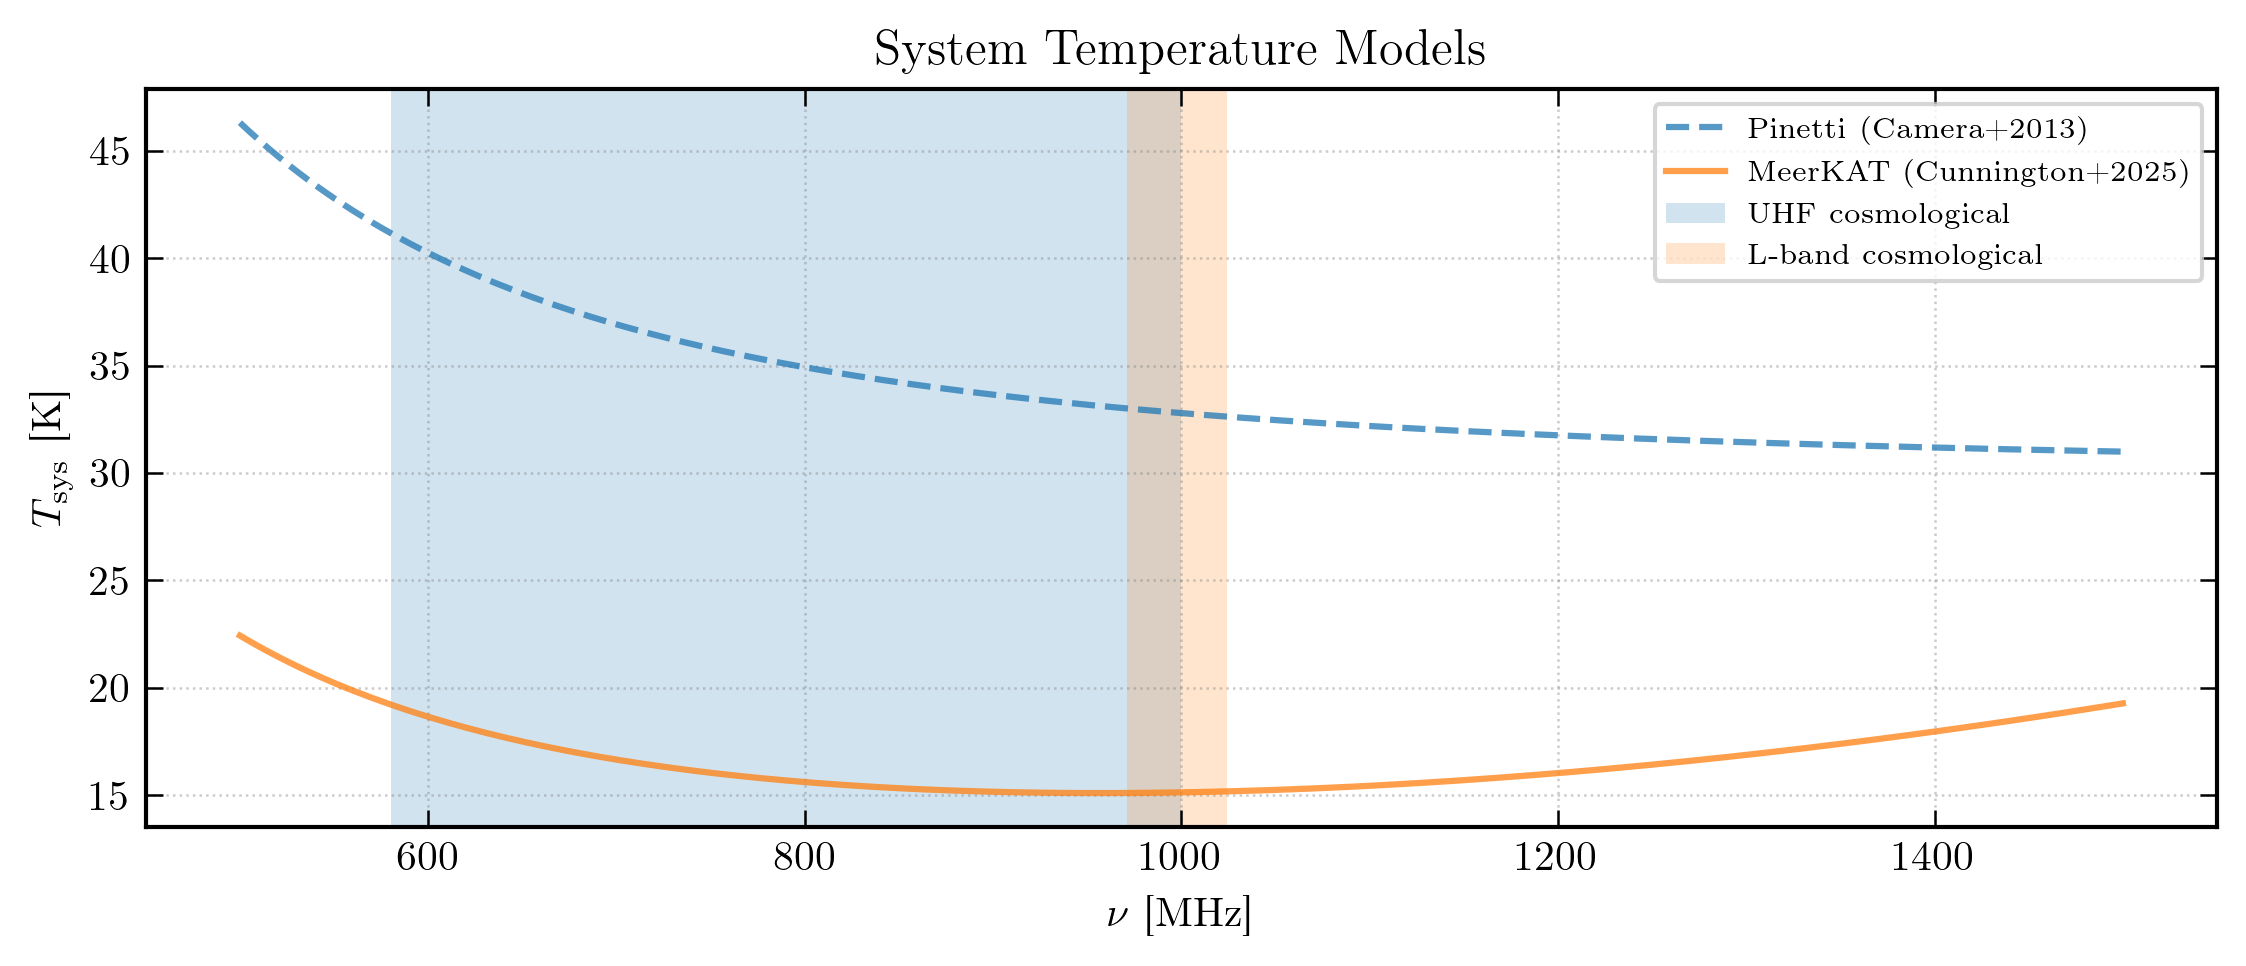

In [ ]:
nu = np.linspace(500, 1500, 200)  # MHz
fig, ax = sty.textwidth_figure(7)
ax.plot(nu, nm.T_sys_pinetti(nu), **sty.MODEL_STYLE, label='Pinetti (Camera+2013)')
ax.plot(nu, nm.T_sys_meerkat(nu), **sty.FIT_STYLE, label='MeerKAT (Cunnington+2025)')
ax.axvspan(580, 1000, **sty.FILL_STYLE, color='C0', label='UHF cosmological')
ax.axvspan(971, 1024, **sty.FILL_STYLE, color='C1', label='L-band cosmological')
ax.set_xlabel(r'$\nu$ [MHz]'); ax.set_ylabel(r'$T_\mathrm{sys}$ [K]')
ax.set_title('System Temperature Models'); ax.legend(fontsize=sty.LEGEND_SIZE); fig.tight_layout()

\
## 2. Beam Window Functions (Eqs. 8.2, 8.7–8.8)

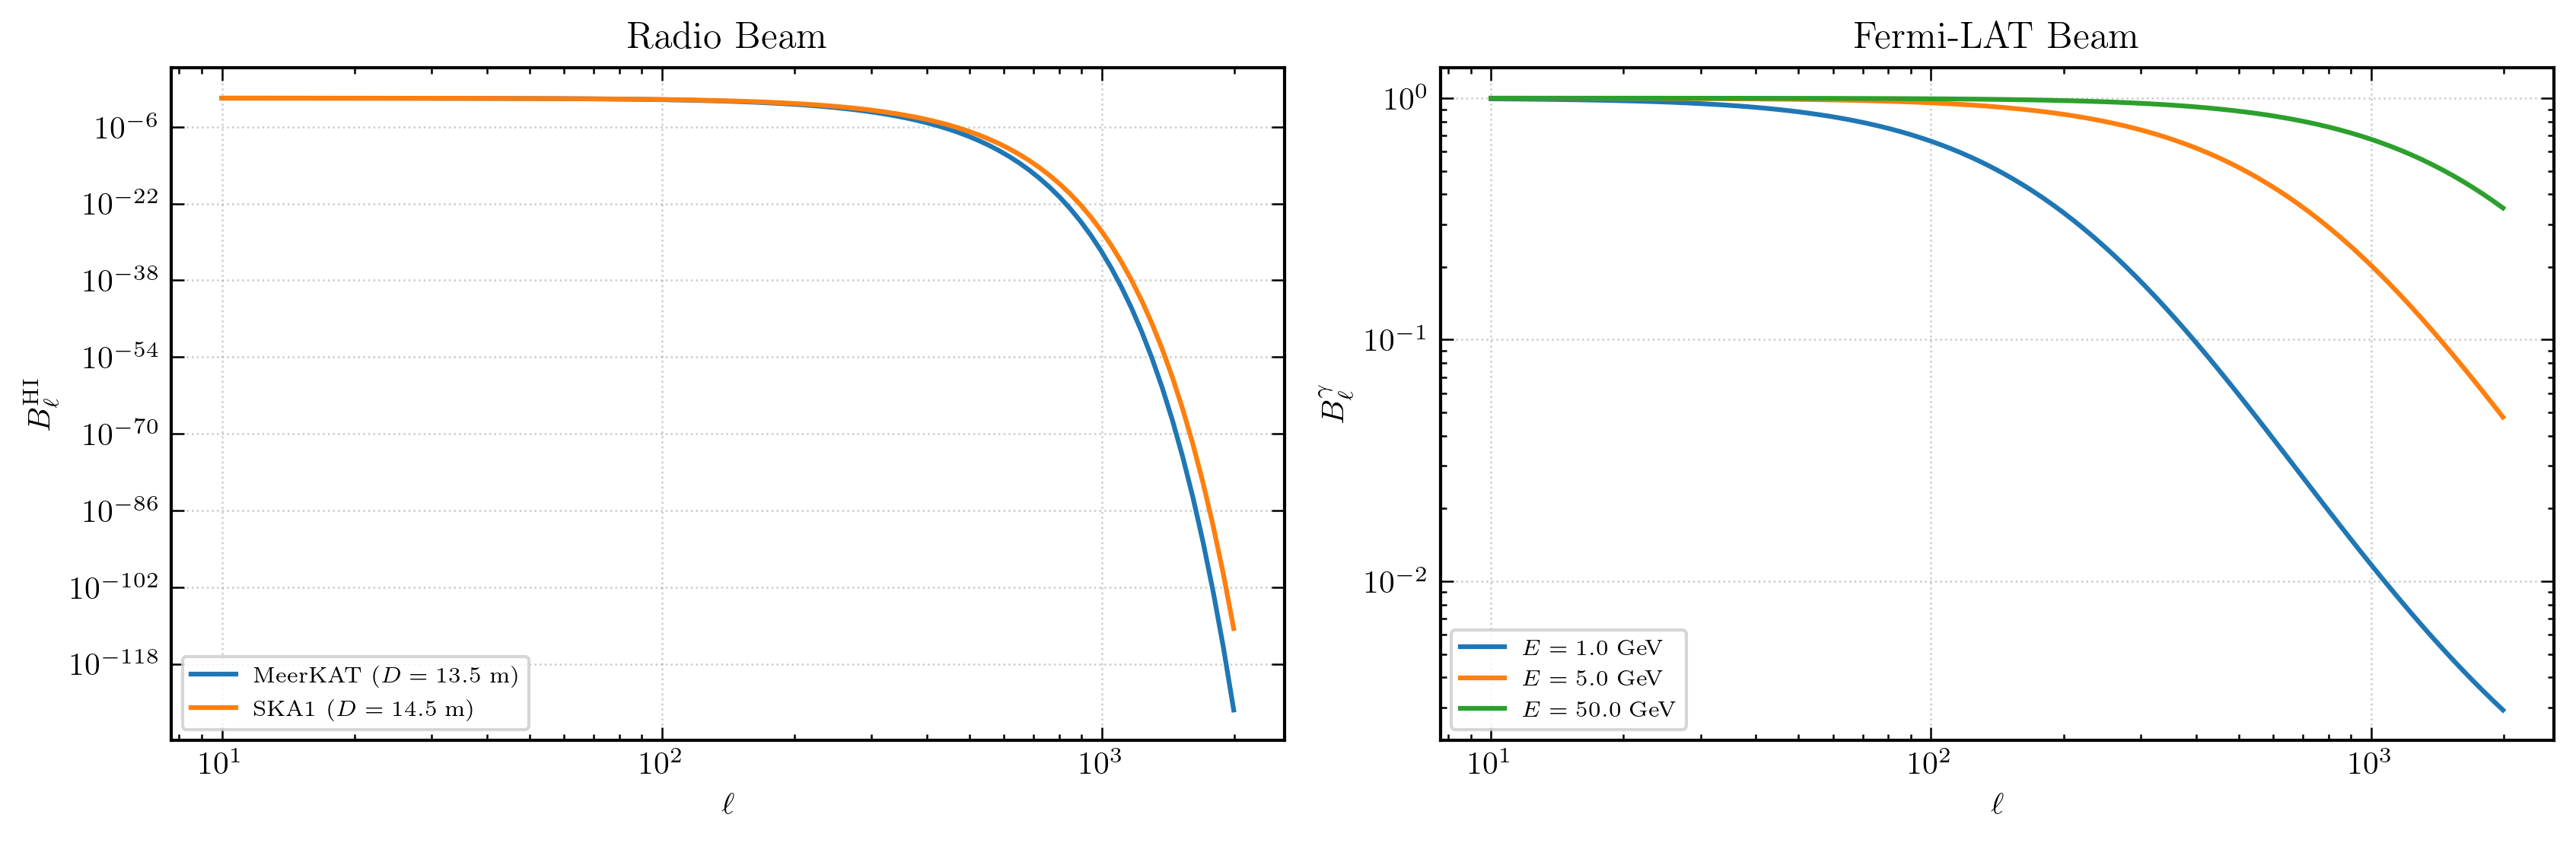

In [ ]:
ell_b = np.logspace(1, 3.3, 100)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(sty.TEXTWIDTH_IN * 1.5, sty.TEXTWIDTH_IN * 0.5))

# Radio beams
for tel, D, color in [('MeerKAT', 13.5, 'C0'), ('SKA1', 14.5, 'C1')]:
    B = nm.beam_radio(ell_b, 0.5, D)
    ax1.semilogy(ell_b, B, color=color, lw=sty.LW_STANDARD, label=f'{tel} ($D={D}$ m)')
ax1.set_xlabel(r'$\ell$'); ax1.set_ylabel(r'$B_\ell^\mathrm{HI}$')
ax1.set_title('Radio Beam'); ax1.set_xscale('log'); ax1.legend(fontsize=sty.LEGEND_SIZE)

# Fermi beams
for E, color in [(1.0, 'C0'), (5.0, 'C1'), (50.0, 'C2')]:
    ax2.semilogy(ell_b, nm.beam_fermi(ell_b, E), color=color, lw=sty.LW_STANDARD,
                 label=f'$E={E}$ GeV')
ax2.set_xlabel(r'$\ell$'); ax2.set_ylabel(r'$B_\ell^\gamma$')
ax2.set_title('Fermi-LAT Beam'); ax2.set_xscale('log'); ax2.legend(fontsize=sty.LEGEND_SIZE)
fig.tight_layout()

\
## 3. Radio Noise Components (Eqs. 8.3–8.6)

In [ ]:
ell_n = np.logspace(1, 3.3, 100)
tel, band = 'MeerKAT', 'UHF'
z_mid = 0.5 * (cfg.RADIO_TELESCOPES[tel]['bands'][band]['z_min'] +
                cfg.RADIO_TELESCOPES[tel]['bands'][band]['z_max'])
N_d = nm.noise_dish(z_mid, tel, band)
N_c = nm.noise_radio_combined(ell_n, tel, band)
lc = nm.ell_cut(tel, band)

fig, ax = sty.textwidth_figure(7)
ax.axhline(N_d, **sty.MODEL_STYLE, label='Dish')
ax.semilogy(ell_n, N_c, **sty.FIT_STYLE, label='Combined')
ax.axvline(lc, **sty.GUIDE_STYLE, label=rf'$\ell_{{\mathrm{{cut}}}}={lc:.0f}$')
ax.set_xlabel(r'$\ell$'); ax.set_ylabel(r'$N^\mathrm{HI}$ [mK$^2$ sr]')
ax.set_title(f'Radio Noise: {tel} {band}'); ax.set_xscale('log')
ax.legend(fontsize=7); fig.tight_layout()

## 3b. Gaussian Variance (Eq. 10.1)

$$(\Delta C_\ell)^2 = \frac{1}{(2\ell+1)\,f_\mathrm{sky}}
\;\frac{N^\gamma}{(B_\ell^\gamma)^2}
\;\left[C_\ell^\mathrm{HI} + \frac{N^\mathrm{HI}}{(B_\ell^\mathrm{HI})^2}\right]$$

The variance factorizes into a gamma-ray noise term and an HI noise term,
both beam-diluted. At high $\ell$ the beams suppress the signal faster than
the noise, so $\Delta C_\ell$ grows exponentially.

\
## 4. SNR Forecast (Eq. 10.2)

$$\mathrm{SNR}^2 = \sum_{\ell,E}\left[\frac{C_\ell^{\mathrm{HI}\times\gamma_\star}}
{\Delta C_\ell}\right]^2$$

  MeerKLASS_L_pilot         L       SNR = 0.27
  MeerKLASS_L_deepfield     L       SNR = 0.35


  MeerKLASS_2024_HI         UHF     SNR = 2.87
  MeerKLASS_XLP_2028        UHF     SNR = 5.59


  MeerKAT                   UHF     SNR = 2.46


  SKA1                      Band2   SNR = 2.02
  SKA2                      Band2   SNR = 2.16


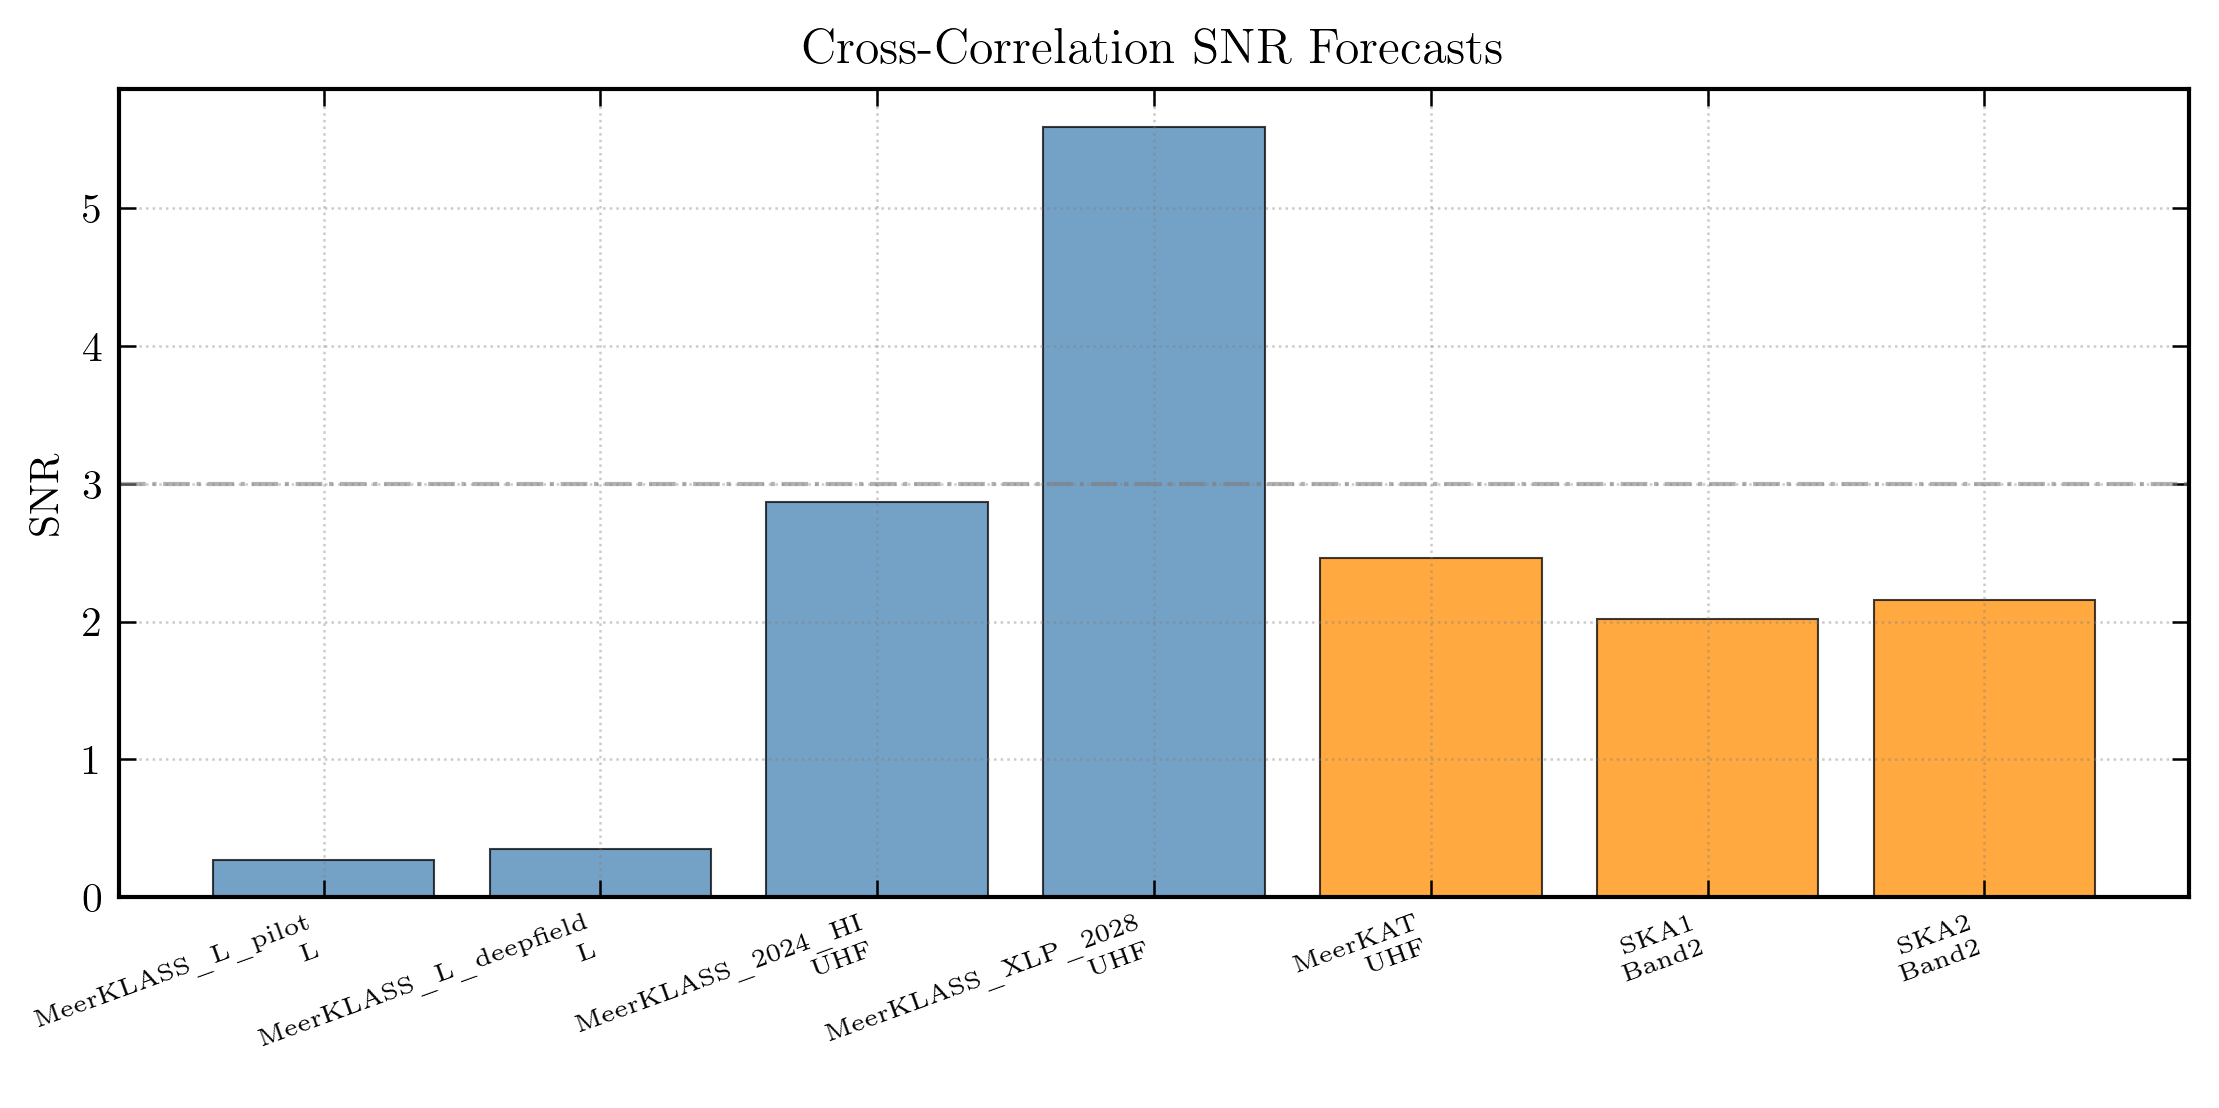

In [ ]:
configs = [
    ('MeerKLASS_L_pilot', 'L'), ('MeerKLASS_L_deepfield', 'L'),
    ('MeerKLASS_2024_HI', 'UHF'), ('MeerKLASS_XLP_2028', 'UHF'),
    ('MeerKAT', 'UHF'), ('SKA1', 'Band2'), ('SKA2', 'Band2'),
]
snr_vals = []
for tel, bnd in configs:
    snr = stats.compute_SNR(tel, bnd, ell_min=10, ell_max=500,
                            n_ell=20, n_z=8, n_M=12)
    snr_vals.append(snr)
    print(f'  {tel:25s} {bnd:6s}  SNR = {snr:.2f}')

fig, ax = sty.textwidth_figure(8)
labels = [f'{t}\n{b}' for t, b in configs]
x = np.arange(len(labels))
colors_bar = ['steelblue' if cfg.RADIO_TELESCOPES[t]['default_hi_brightness'] == 'cunnington'
              else 'darkorange' for t, _ in configs]
ax.bar(x, snr_vals, color=colors_bar, alpha=sty.ALPHA_STANDARD, edgecolor='k', linewidth=sty.LW_FINE)
ax.axhline(3.0, **sty.GUIDE_STYLE)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=sty.TICK_SIZE, rotation=20, ha='right')
ax.set_ylabel('SNR'); ax.set_title('Cross-Correlation SNR Forecasts')
fig.tight_layout()

\
## 5. DM Exclusion Curve (Eqs. 10.3–10.4)

$$\sigma_v^\mathrm{excl} = \sigma_v^\mathrm{test}\,
\sqrt{\Delta\chi^2_\mathrm{threshold}/\Delta\chi^2_\mathrm{test}},\qquad
\Delta\chi^2_{95\%} = 4$$

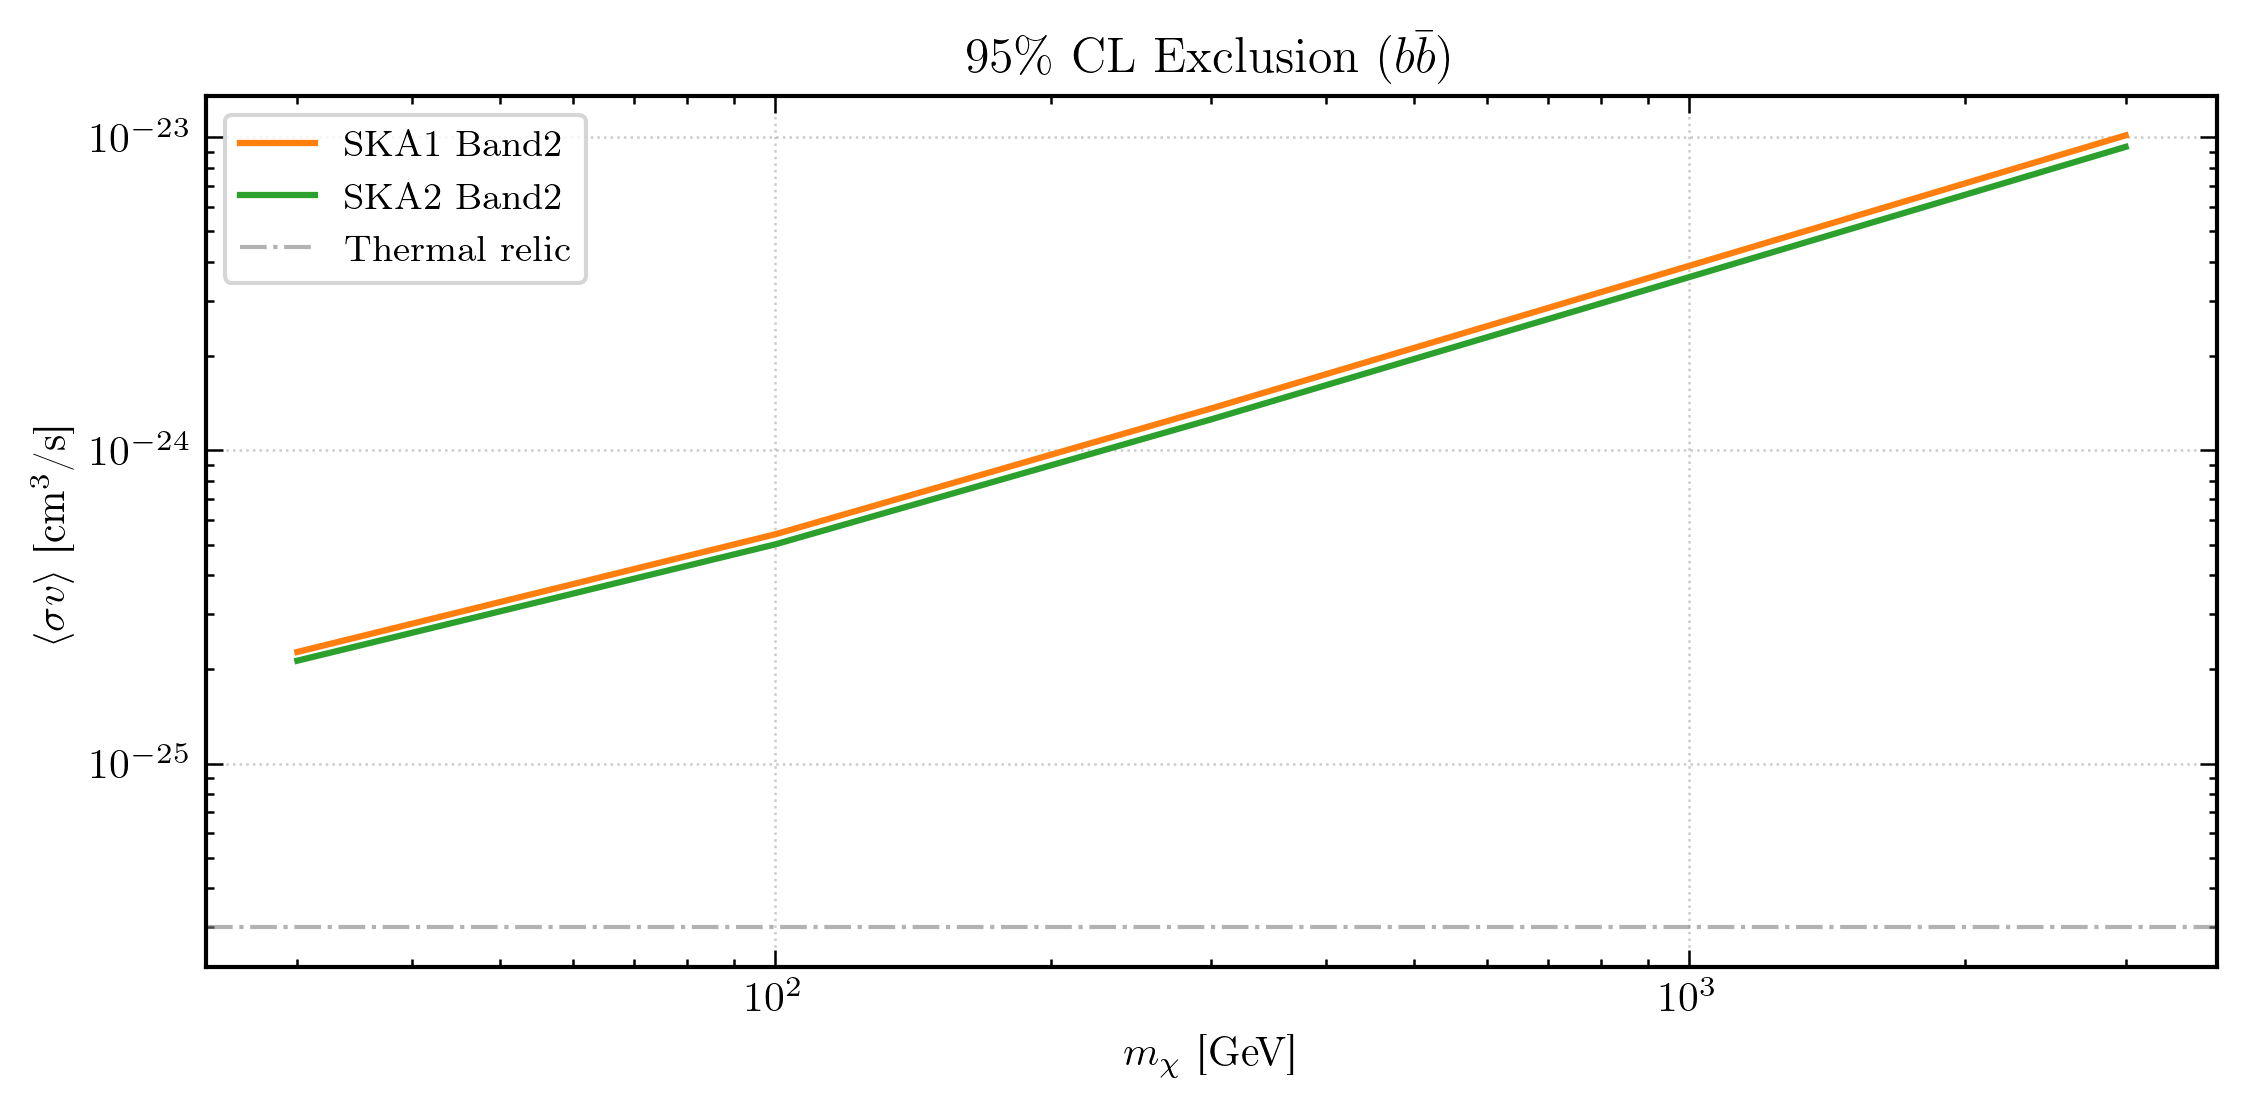

In [ ]:
m_arr = np.array([30., 100., 300., 1000., 3000.])
fig, ax = sty.textwidth_figure(8)
for tel, bnd, color in [('SKA1', 'Band2', 'C1'), ('SKA2', 'Band2', 'C2')]:
    m, sv = stats.exclusion_curve(tel, bnd, m_chi_arr=m_arr, n_ell=8, n_z=5, n_M=6)
    ax.loglog(m, sv, color=color, lw=sty.LW_STANDARD, label=f'{tel} {bnd}')
ax.axhline(cfg.SIGMA_V_THERMAL, **sty.GUIDE_STYLE, label='Thermal relic')
ax.set_xlabel(r'$m_\chi$ [GeV]'); ax.set_ylabel(r'$\langle\sigma v\rangle$ [cm$^3$/s]')
ax.set_title(r'95\% CL Exclusion ($b\bar{b}$)'); ax.legend(); fig.tight_layout()